Running Capacity/Tolerance Sweep...


100%|██████████| 15/15 [00:37<00:00,  2.48s/it]


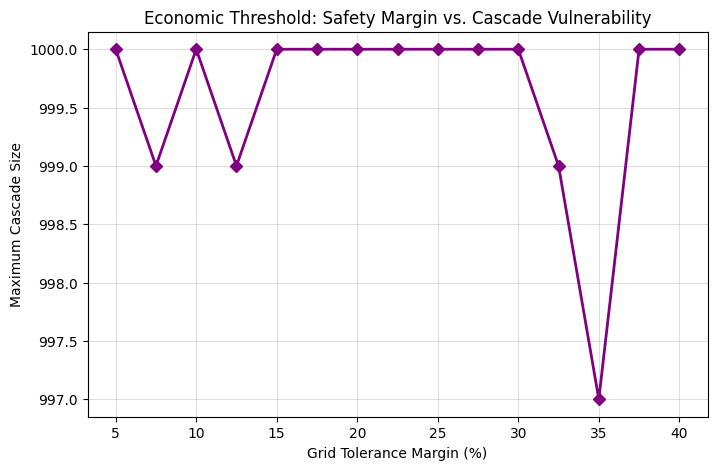

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_max_cascade_for_tolerance(tolerance, RADIUS=0.06):
    NUM_NODES, NOISE, STEPS = 1000, 0.8, 1500
    G = nx.random_geometric_graph(NUM_NODES, radius=RADIUS)

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + tolerance)
        G.nodes[node]['tripped'] = False

    max_avalanche = 0

    for step in range(STEPS):
        for node in G.nodes(): G.nodes[node]['load'] += (NOISE / 10.0)
        current_avalanche = 0

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche += 1

                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs: G.nodes[nbr]['load'] += spill

        if current_avalanche > max_avalanche:
            max_avalanche = current_avalanche

        for node in G.nodes(): G.nodes[node]['tripped'] = False

    return max_avalanche

# --- THE TOLERANCE SWEEP ---
tolerances = np.linspace(0.05, 0.40, 15)
max_cascades = []

print("Running Capacity/Tolerance Sweep...")
for tol in tqdm(tolerances):
    max_cascades.append(get_max_cascade_for_tolerance(tol))

# --- PLOTTING ---
plt.figure(figsize=(8, 5))
plt.plot(tolerances * 100, max_cascades, marker='D', color='purple', linewidth=2)
plt.title("Economic Threshold: Safety Margin vs. Cascade Vulnerability")
plt.xlabel("Grid Tolerance Margin (%)")
plt.ylabel("Maximum Cascade Size")
plt.grid(True, alpha=0.4)
plt.show()